In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('Iris.csv')
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [3]:
df.drop(columns=["Id"], inplace=True)  

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df.isnull().sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

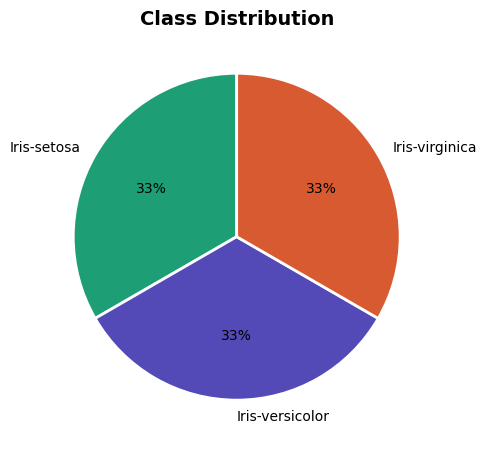

Saved: 1_pie_chart.png


In [9]:
counts = df["Species"].value_counts()
 
plt.figure(figsize=(5, 5))
plt.pie(
    counts,
    labels=counts.index,
    autopct="%1.0f%%",
    colors=["#1D9E75", "#534AB7", "#D85A30"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
plt.title("Class Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("1_pie_chart.png", dpi=150)
plt.show()
print("Saved: 1_pie_chart.png")

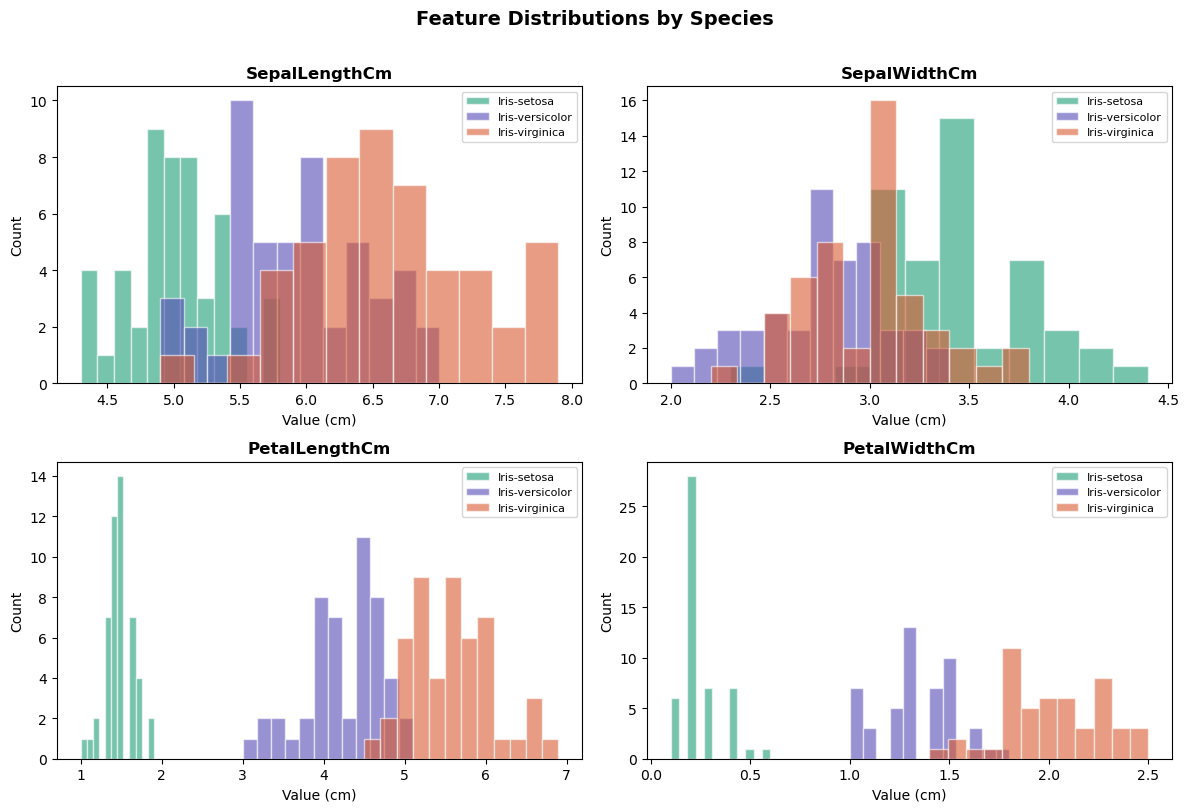

Saved: 2_histograms.png


In [10]:
features = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
colors   = {"Iris-setosa": "#1D9E75",
            "Iris-versicolor": "#534AB7",
            "Iris-virginica": "#D85A30"}
 
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
 
for i, feat in enumerate(features):
    for species, grp in df.groupby("Species"):
        axes[i].hist(
            grp[feat],
            bins=12,
            alpha=0.6,
            label=species,
            color=colors[species],
            edgecolor="white"
        )
    axes[i].set_title(feat, fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Value (cm)")
    axes[i].set_ylabel("Count")
    axes[i].legend(fontsize=8)
 
plt.suptitle("Feature Distributions by Species", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("2_histograms.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 2_histograms.png")

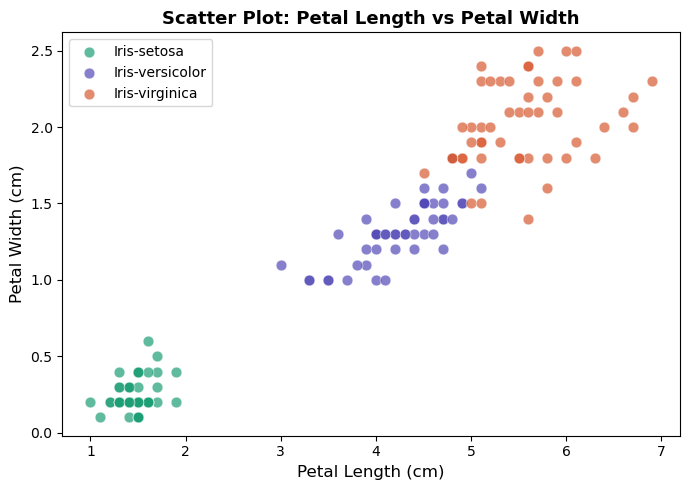

Saved: 3_scatter.png


In [11]:
plt.figure(figsize=(7, 5))
 
for species, grp in df.groupby("Species"):
    plt.scatter(
        grp["PetalLengthCm"],
        grp["PetalWidthCm"],
        label=species,
        color=colors[species],
        alpha=0.7,
        edgecolors="white",
        linewidth=0.5,
        s=60
    )
 
plt.xlabel("Petal Length (cm)", fontsize=12)
plt.ylabel("Petal Width (cm)", fontsize=12)
plt.title("Scatter Plot: Petal Length vs Petal Width", fontsize=13, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("3_scatter.png", dpi=150)
plt.show()
print("Saved: 3_scatter.png")

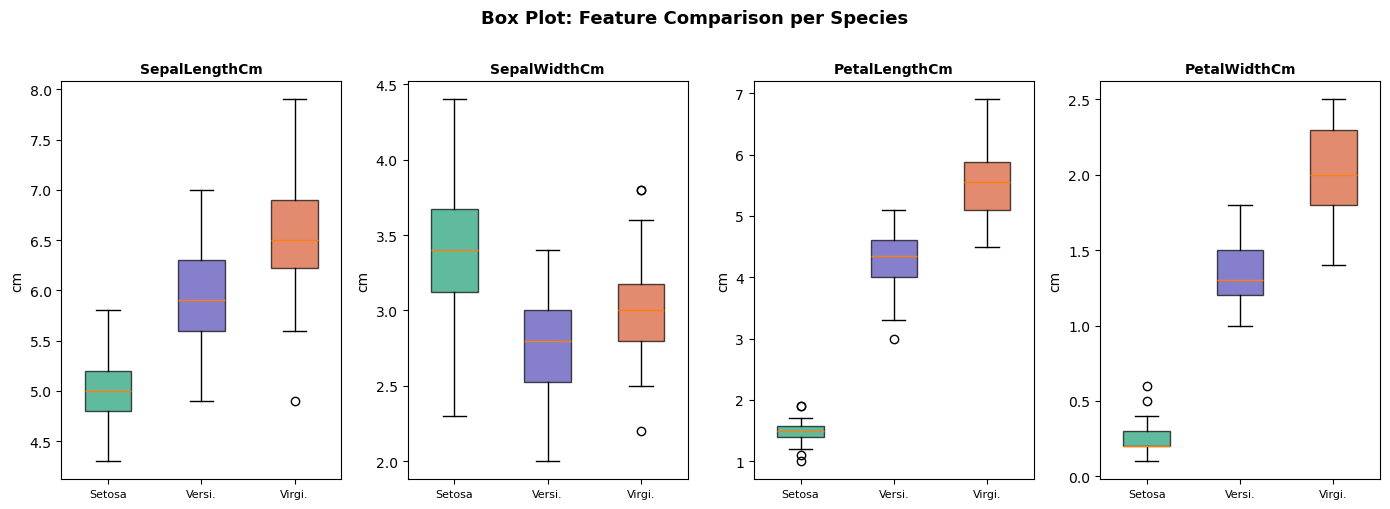

Saved: 4_boxplot.png


In [12]:
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
 
for i, feat in enumerate(features):
    species_data = [df[df["Species"] == sp][feat].values
                    for sp in df["Species"].unique()]
 
    bp = axes[i].boxplot(
        species_data,
        patch_artist=True,
        notch=False,
        widths=0.5
    )
 
    for patch, color in zip(bp["boxes"], colors.values()):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
 
    axes[i].set_title(feat, fontsize=10, fontweight="bold")
    axes[i].set_xticklabels(["Setosa", "Versi.", "Virgi."], fontsize=8)
    axes[i].set_ylabel("cm")
 
plt.suptitle("Box Plot: Feature Comparison per Species",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("4_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 4_boxplot.png")

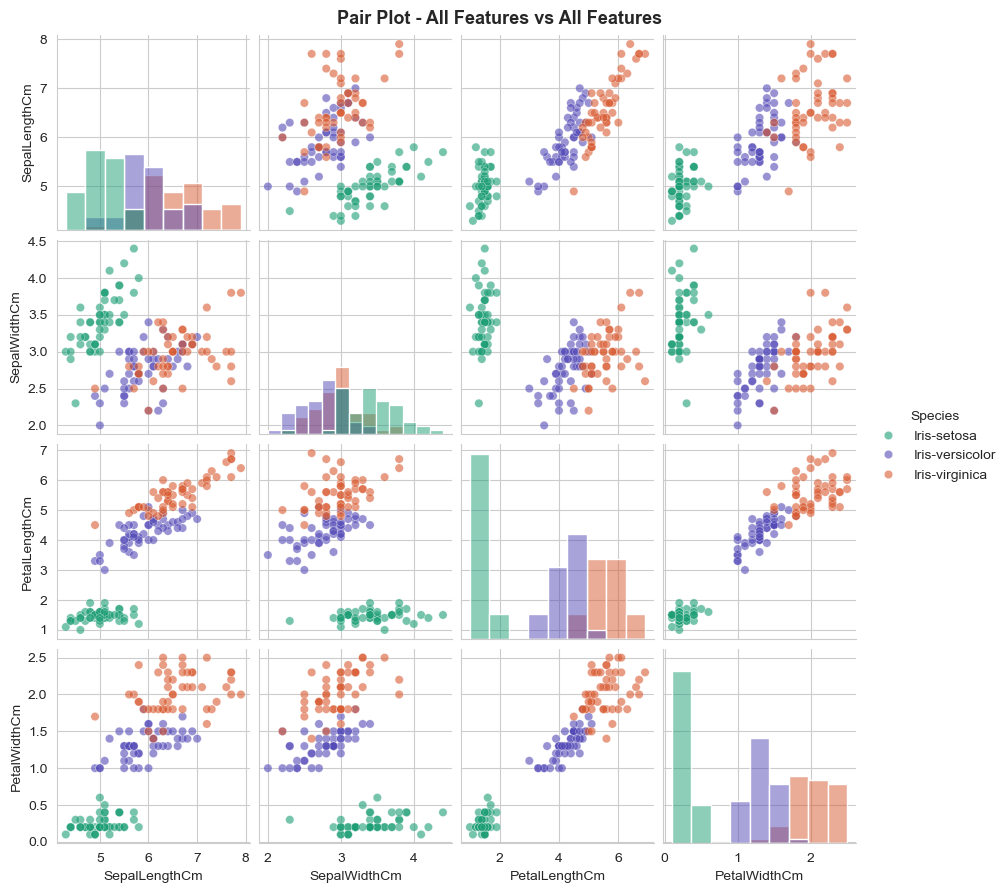

Saved: 5_pairplot.png


In [13]:
sns.set_style("whitegrid")
pair = sns.pairplot(
    df,
    hue="Species",
    palette={"Iris-setosa": "#1D9E75",
             "Iris-versicolor": "#534AB7",
             "Iris-virginica": "#D85A30"},
    diag_kind="hist",
    plot_kws={"alpha": 0.6, "edgecolor": "white", "linewidth": 0.3},
    height=2.2
)
pair.figure.suptitle("Pair Plot - All Features vs All Features",
                  y=1.01, fontsize=13, fontweight="bold")
plt.savefig("5_pairplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 5_pairplot.png")

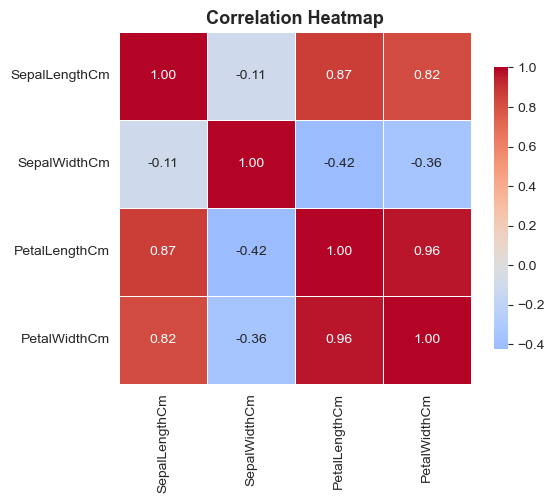

Saved: 6_heatmap.png


In [14]:
plt.figure(figsize=(6, 5))
corr = df[features].corr()
 
sns.heatmap(
    corr,
    annot=True,          # andar numbers dikhao
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("6_heatmap.png", dpi=150)
plt.show()
print("Saved: 6_heatmap.png")
 

In [15]:
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [16]:
# y=df[['Species']].copy()
x=df.drop(columns=['Species'])
x

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [17]:
y=df['Species'].copy()
y

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
149    Iris-virginica
Name: Species, Length: 150, dtype: object

In [18]:
y.shape

(150,)

In [19]:
# from sklearn.model_selection import train_test_split
# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [20]:
# x_train

In [21]:
# y_train

In [22]:
# train_counts = y_train.value_counts().sort_index()
# test_counts  = y_test.value_counts().sort_index()
 
# print("Train set counts:")
# print(train_counts)
# print("\nTest set counts:")
# print(test_counts)

In [23]:
#Using Stratified Shuffle split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [24]:
x_train

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
8,4.4,2.9,1.4,0.2
106,4.9,2.5,4.5,1.7
76,6.8,2.8,4.8,1.4
9,4.9,3.1,1.5,0.1
89,5.5,2.5,4.0,1.3
...,...,...,...,...
37,4.9,3.1,1.5,0.1
2,4.7,3.2,1.3,0.2
33,5.5,4.2,1.4,0.2
52,6.9,3.1,4.9,1.5


In [25]:
y_train

8          Iris-setosa
106     Iris-virginica
76     Iris-versicolor
9          Iris-setosa
89     Iris-versicolor
            ...       
37         Iris-setosa
2          Iris-setosa
33         Iris-setosa
52     Iris-versicolor
3          Iris-setosa
Name: Species, Length: 120, dtype: object

In [26]:
train_counts = y_train.value_counts().sort_index()
test_counts  = y_test.value_counts().sort_index()
 
print("Train set counts:")
print(train_counts)
print("\nTest set counts:")
print(test_counts)

Train set counts:
Species
Iris-setosa        40
Iris-versicolor    40
Iris-virginica     40
Name: count, dtype: int64

Test set counts:
Species
Iris-setosa        10
Iris-versicolor    10
Iris-virginica     10
Name: count, dtype: int64


In [42]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix

In [39]:
# Step 1 - Sirf model banao, fit mat karo
tree_cl = DecisionTreeClassifier()
scores = cross_val_score(tree_cl, x_train, y_train, cv=5)
print(f"Decision Tree Classifier: {scores.mean()*100:.2f}%")
print(scores)

Decision Tree Classifier: 94.17%
[0.91666667 0.95833333 0.95833333 0.95833333 0.91666667]


In [ ]:
models = {
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Logistic Regression': LogisticRegression(),
    'KNN': Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())]),
    'SVM': Pipeline([('scaler', StandardScaler()), ('svm', SVC())])
}

for name, model in models.items():
    scores = cross_val_score(model, x_train, y_train, cv=5, scoring='accuracy')
    print(f"{name:<20} {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%")


Decision Tree        94.17% ± 2.04%
Random Forest        95.00% ± 1.67%
Logistic Regression  96.67% ± 1.67%
[0.95833333 0.95833333 0.95833333 0.95833333 1.        ]
KNN                  96.67% ± 3.12%
SVM                  96.67% ± 3.12%


In [ ]:
#Fitting Best model
log_cl = LogisticRegression()
log_cl.fit(x_train, y_train)

# Final prediction x_test par
log_pred = log_cl.predict(x_test)
print(classification_report(y_test, log_pred))


                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



In [48]:
cm=confusion_matrix(y_test,log_pred)
print(cm)

[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


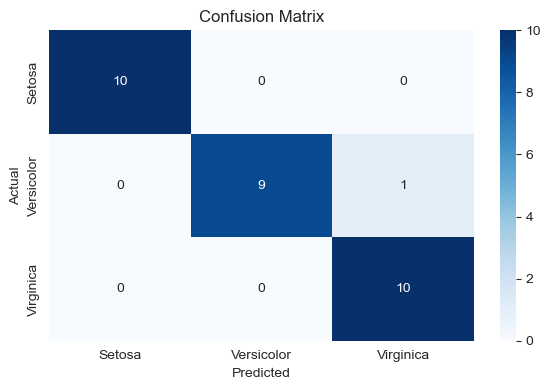

In [47]:

plt.figure(figsize=(6,4))
sns.heatmap(cm, 
            annot=True, 
            fmt='d',
            xticklabels=['Setosa','Versicolor','Virginica'],
            yticklabels=['Setosa','Versicolor','Virginica'],
            cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()